In [1]:
from sklearn.datasets import  fetch_openml
import pandas as pd
### Import Packages ###

import os
import math as math
import pandas as pd
import random as random

### Append Path ###
import sys
sys.path.append('..')

### Local Packages ###
from utils.Prediction import *
from utils.Selector import *
from utils.Auxiliary import *
from utils.Main import *

boston = fetch_openml(name="boston", version=1, as_frame=True)
df_boston = pd.DataFrame(boston.data, columns=boston.feature_names)
df_boston['target'] = boston.target

datasets = {
    #"Diabetes": df_diabetes,
    # "CaliforniaHousing": df_california,
     "BostonHousing": df_boston,
    # "AmesHousing": df_ames,
}

def drop_non_numeric_columns(df, label_col="Y"):
    """Drops all non-numeric columns (except your label col, if you want to keep it)."""
    # Separate the label from the features
    features_df = df.loc[:, df.columns != label_col]
    label_series = df[label_col] if label_col in df.columns else None

    # Keep only numeric columns
    numeric_features_df = features_df.select_dtypes(include=["number"]).copy()

    # Reattach the label if present
    if label_series is not None:
        numeric_features_df[label_col] = label_series
    
    return numeric_features_df

# Example usage:
for dataset_name, df in datasets.items():
    datasets[dataset_name] = drop_non_numeric_columns(df, label_col="Y")


for key, df in datasets.items():
    if "target" in df.columns:
        df.rename(columns={"target": "Y"}, inplace=True)
import os


for name, df in datasets.items():
    filename = os.path.join("dataset_files", f"{name}.pkl")
    df.to_pickle(filename)
    print(f"Saved {name} dataset as {filename}")



# 2. Define your model and selector lists
model_types = [
     #"LinearRegressionFunction",
     "RidgeRegressionFunction",
    #"RandomForestRegressorFunction",
    #"XGBoostRegressorFunction",
    #"NeuralNetworkFunction"
]


selector_types = [
    "PassiveLearning",
    #"GSxFunction",            
    # "GSxFunctionAverage",      
    "GSyFunction",              
    # "GSyFunctionAverage",     
    #"iGSFunction",             
    # "iGSFunctionAverage",     
    #"iGSFunctionStandardized", 
    #"iGSFunctionAverageStandardized",
    #"WiGSFunction_linear",
    #"WiGSFunction_exponential",
    #"WiGSFunction_adaptive"
]

#for ridge regression use 0.01 alpha

# Import or define your OneIterationFunction and TrainTestCandidateSplit functions
from utils.Main import OneIterationFunction, TrainTestCandidateSplit
 
all_results = run_active_learning_experiments(
    datasets=datasets,
    model_types=model_types,
    selector_types=selector_types,
    OneIterationFunction=OneIterationFunction,
    TrainTestCandidateSplit=TrainTestCandidateSplit,
    n_simulations=2,          # Use 1 for a quick run; set 100+ for full experiments
    test_proportion=0.2,
    candidate_proportion=0.8,
    plot=True,
    do_wilcoxon=True,
    round_wilcoxon=4,
    output_dir="results"
)


Saved BostonHousing dataset as dataset_files\BostonHousing.pkl

=== DATASET: BostonHousing | MODEL: RidgeRegressionFunction ===
Iteration: 0
Iteration: 1
Iteration: 2
Iteration: 3
Iteration: 4
Iteration: 5
Iteration: 6
Iteration: 7
Iteration: 8
Iteration: 9
Iteration: 10
Iteration: 11
Iteration: 12
Iteration: 13
Iteration: 14
Iteration: 15
Iteration: 16
Iteration: 17
Iteration: 18
Iteration: 19
Iteration: 20
Iteration: 21
Iteration: 22
Iteration: 23
Iteration: 24
Iteration: 25
Iteration: 26
Iteration: 27
Iteration: 28
Iteration: 29
Iteration: 30
Iteration: 31
Iteration: 32
Iteration: 33
Iteration: 34
Iteration: 35
Iteration: 36
Iteration: 37
Iteration: 38
Iteration: 39
Iteration: 40
Iteration: 41
Iteration: 42
Iteration: 43
Iteration: 44
Iteration: 45
Iteration: 46
Iteration: 47
Iteration: 48
Iteration: 49
Iteration: 50
Iteration: 51
Iteration: 52
Iteration: 53
Iteration: 54
Iteration: 55
Iteration: 56
Iteration: 57
Iteration: 58
Iteration: 59
Iteration: 60
Iteration: 61
Iteration: 62


In [1]:
#DONT RUN UNLESS YOU WANT TO SAVE THE RESULTS TO THE FILE LISTED
#WILL OVERWRITE THE FILE

import pickle
# make sure the folder exists
import os
os.makedirs("results", exist_ok=True)
import os
print(os.path.isdir("results"))

# Save to disk
with open("results/*****ENTER NAME *****.pkl", "wb") as f:
    pickle.dump(all_results, f)
print("all_results saved to results/*****ENTER NAME *****.pkl")

True


NameError: name 'all_results' is not defined

In [2]:
import pickle
with open("results/all_results.pkl", "rb") as f:
    all_results = pickle.load(f)
print("Reloaded all_results; keys:", list(all_results.keys())[:5], "…")

EOFError: Ran out of input

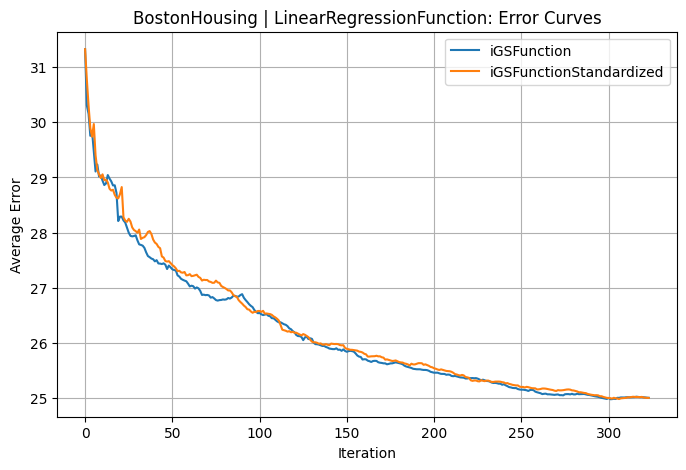

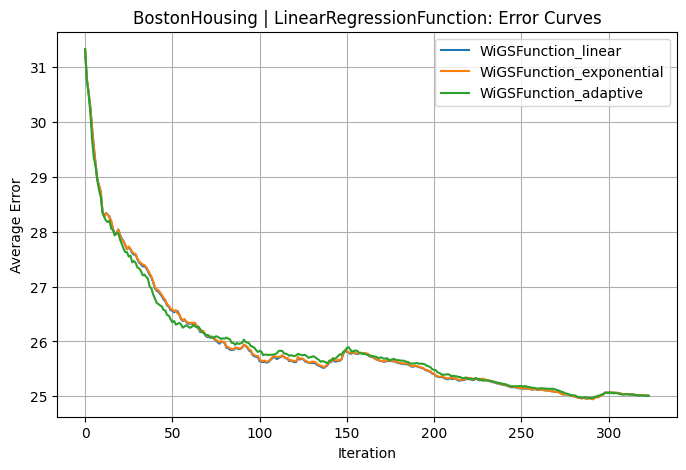

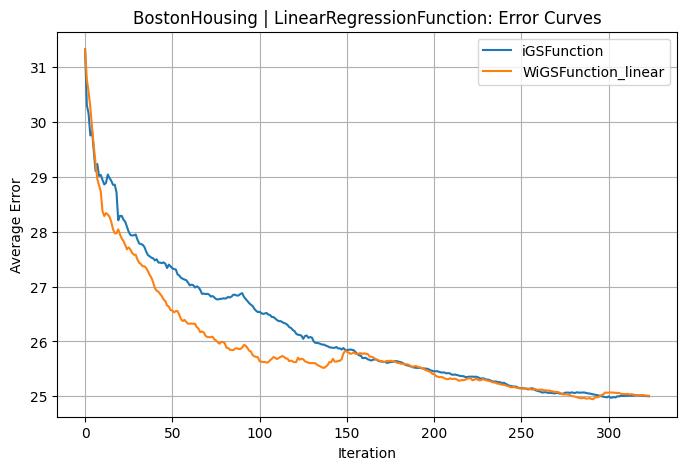

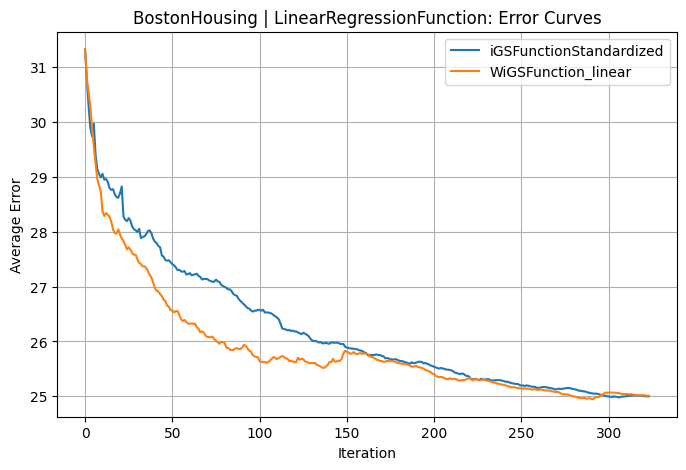

In [4]:
import matplotlib.pyplot as plt

def plot_custom_error_curves(results_summary, dataset_name, model_name, selectors=None):
    """
    Plot custom error curves for specified selectors from the results_summary.

    Parameters
    ----------
    results_summary : dict
        Output of run_active_learning_experiments.
    dataset_name : str
        Name of the dataset (key[0] in results_summary).
    model_name : str
        Name of the model (key[1] in results_summary).
    selectors : list of str, optional
        Specific selector names to plot. If None, plots all selectors for that dataset+model.
    """
    # collect keys matching dataset and model
    keys = [key for key in results_summary
            if key[0] == dataset_name and key[1] == model_name]
    available = [key[2] for key in keys]
    to_plot = selectors or available

    plt.figure(figsize=(8, 5))
    for sel in to_plot:
        if (dataset_name, model_name, sel) in results_summary:
            info = results_summary[(dataset_name, model_name, sel)]
            plt.plot(info["avg_error"], label=sel)
        else:
            print(f"Selector '{sel}' not found for {dataset_name} + {model_name}")
    plt.xlabel("Iteration")
    plt.ylabel("Average Error")
    plt.title(f"{dataset_name} | {model_name}: Error Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_custom_error_curves(
    all_results,
    "BostonHousing",
    "LinearRegressionFunction",
    selectors=["iGSFunction", "iGSFunctionStandardized"]
)

plot_custom_error_curves(
    all_results,
    "BostonHousing",
    "LinearRegressionFunction",
    selectors=["WiGSFunction_linear", "WiGSFunction_exponential", "WiGSFunction_adaptive"]
)
plot_custom_error_curves(
    all_results,
    "BostonHousing",
    "LinearRegressionFunction",
    selectors=["iGSFunction", "WiGSFunction_linear"]
)

plot_custom_error_curves(
    all_results,
    "BostonHousing",
    "LinearRegressionFunction",
    selectors=["iGSFunctionStandardized", "WiGSFunction_linear"]
)

